#### 5.1 Labelling PCs

In [1]:
#### 12.30
#### We're changing the Enterocyte label to Enterocyte Progenitor to better reflect the early timepoint.
#### Then, create a new .obs metadata column, and store a new 'Secretory PC' label, based on the expression of SOX4 in the PCs

#### Import python single cell stack

In [2]:
## Python single cell stack


import scanpy as sc

import pandas as pd
import numpy as np
from scipy import sparse
from scipy.sparse import issparse

## Plotting

import matplotlib.pyplot as plt
import seaborn as sns

## Paths and system

import os, sys
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR


#### Load in our object

In [ ]:

d2_lapa_clustered = sc.read_h5ad(ANALYSIS_DIR / "manual_labelled/d2_lapa_manual_labels.h5ad")

#### Change the Enterocytes to Enterocyte PCs

In [ ]:
## Check this is categorical
d2_lapa_clustered.obs['manual_label'].dtype

CategoricalDtype(categories=['Enterocytes', 'ISCs', 'Inflammed progenitor cells', 'PCs',
                  'Proliferating progenitor cells',
                  'Secretory progenitor cells'],
, ordered=False, categories_dtype=object)

In [ ]:
d2_lapa_clustered.obs['manual_label'] = d2_lapa_clustered.obs['manual_label'].cat.rename_categories({
    "Enterocytes": "Enterocyte PCs"
})

#### Create a new layer of metadata, for the inflammed PC label

In [ ]:
d2_lapa_clustered.obs['inflammed_manual_label'] = d2_lapa_clustered.obs['manual_label'].copy()

#### Relabel the inflammed PCs as PCs

In [ ]:
# Reassign cells
d2_lapa_clustered.obs.loc[
    d2_lapa_clustered.obs['manual_label'] == "Inflammed progenitor cells",
    "manual_label"
] = "PCs"


In [ ]:
# Drop the unused label
d2_lapa_clustered.obs['manual_label'] = d2_lapa_clustered.obs['manual_label'].cat.remove_categories(
    ["Inflammed progenitor cells"]
)

#### Plot the results

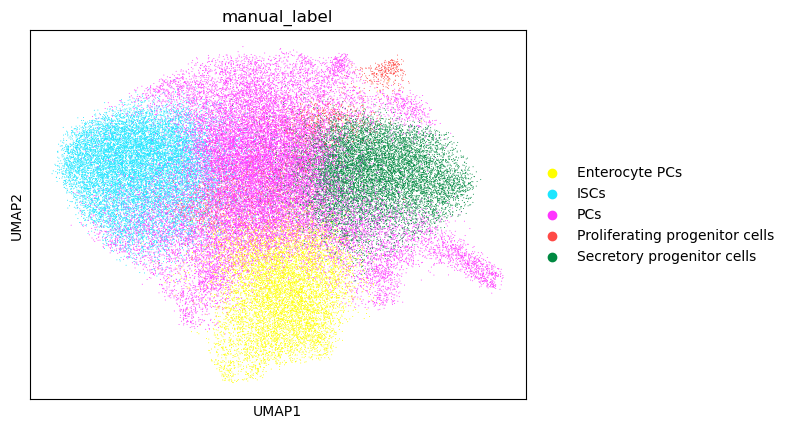

In [ ]:
sc.pl.umap(d2_lapa_clustered, color = 'manual_label')

In [ ]:
#### I'm happy with the 'manual_label' slot, we're going to create another representation in 'manual_label_2', where we define Secretory PCs by gene expression

#### Create a new manual_label_2 slot

In [ ]:
d2_lapa_clustered.obs['manual_label_2'] = d2_lapa_clustered.obs['manual_label'].copy()

In [ ]:
# 2) reassign *in the new slot*
mask = d2_lapa_clustered.obs["manual_label_2"] == "Secretory progenitor cells"
d2_lapa_clustered.obs.loc[mask, "manual_label_2"] = "PCs"

# 3) now it is safe to drop the old category
d2_lapa_clustered.obs["manual_label_2"] = d2_lapa_clustered.obs["manual_label_2"].cat.remove_categories(
    ["Secretory progenitor cells"]
)

#### Define a function for filtering on gene expression

In [ ]:

def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold

#### Create a new Secretory PC 'category' in our new slot

In [ ]:
d2_lapa_clustered.obs["manual_label_2"] = (
    d2_lapa_clustered.obs["manual_label_2"]
    .cat
    .add_categories(["Secretory PCs"])
)

#### Complete the reassignment

In [ ]:
# Secretory PCs: PCs AND SOX4+
sox4_pos = gene_expr_bool(d2_lapa_clustered, "SOX4")
mask_pcs = d2_lapa_clustered.obs["manual_label_2"] == "PCs"
mask_secretory_pcs = mask_pcs & sox4_pos
d2_lapa_clustered.obs.loc[mask_secretory_pcs, "manual_label_2"] = "Secretory PCs"

#### Plot the result

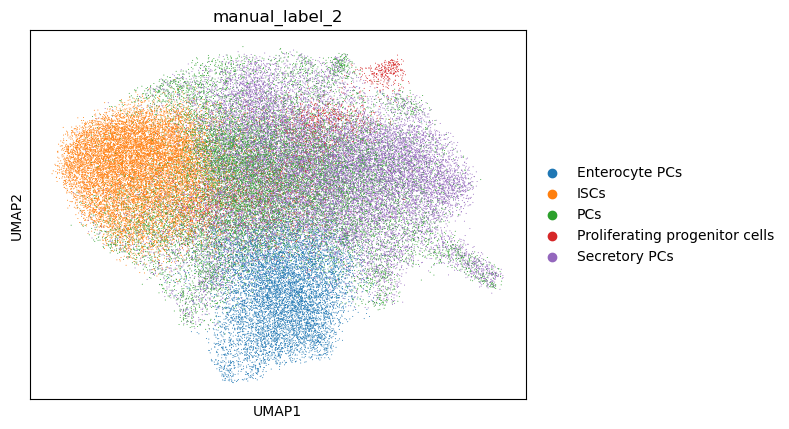

In [ ]:
sc.pl.umap(d2_lapa_clustered, color = 'manual_label_2')

#### Now save the object to the manual_labelled_2 folder

In [ ]:
os.getcwd()

In [ ]:
sc.write(str(ANALYSIS_DIR / "manual_labelled_2/d2_lapa_manual_labels_2.h5ad"), d2_lapa_clustered)